# Predicting H1N1 Flu Vaccine Uptake Using Machine Learning

## Introduction

The 2009 H1N1 influenza pandemic posed a significant global public health challenge. Vaccination was one of the most effective strategies to reduce infection rates and prevent severe outcomes. However, vaccination uptake varied widely across populations.

Understanding the factors that influence whether individuals choose to receive a vaccine is critical for designing effective public health interventions.

This project uses machine learning classification models to predict H1N1 vaccine uptake based on demographic characteristics, health conditions, behavioral patterns, and attitudes toward vaccines.

The goal is not only to build predictive models, but also to identify key drivers of vaccination behavior that can inform public health strategies and improve vaccine outreach efforts.

## Business Understanding

### Stakeholder
The primary stakeholders for this project are public health organizations and policymakers responsible for planning vaccination campaigns.

Their goal is to increase vaccination rates in order to reduce disease spread and protect vulnerable populations.

---

### Business Problem
During the H1N1 pandemic, not all individuals chose to receive the vaccine despite public health efforts.

This creates a challenge for policymakers:
- Why do some people vaccinate while others do not?
- How can vaccination uptake be improved?

---

### Project Objective
The objective of this project is to build a machine learning model that predicts whether an individual received the H1N1 vaccine.

In addition, the project aims to identify the most important factors influencing vaccination decisions.

---

### Key Questions
- What factors influence vaccine uptake?
- Can we accurately predict vaccination behavior?
- Which variables are the strongest predictors?

---

### Success Criteria
A successful model should:
- Achieve strong predictive performance (accuracy, recall, AUC)
- Provide interpretable insights for stakeholders
- Generalize well to unseen data

## Data Understanding

The dataset used in this project comes from the National 2009 H1N1 Flu Survey.

It contains information on:
- Demographics (age, race, sex)
- Health conditions
- Preventive behaviors
- Attitudes toward vaccines

The dataset is provided in two files:

- `training_set_features.csv`: predictor variables
- `training_set_labels.csv`: target variables

Each row represents an individual respondent, and both datasets are merged using `respondent_id`.

The target variable for this project is:
- `h1n1_vaccine` (1 = vaccinated, 0 = not vaccinated)

# Insight:
The dataset contains both numerical and categorical variables, which means preprocessing (encoding + scaling) will be required.

The dataset is imbalanced (≈79% did not vaccinate).This  means accuracy alone is not sufficient.
We will focus on recall, F1-score, and AUC for evaluation.





## Exploratory Data Analysis (EDA) 

## Vaccine distribution

<Axes: xlabel='h1n1_vaccine', ylabel='count'>

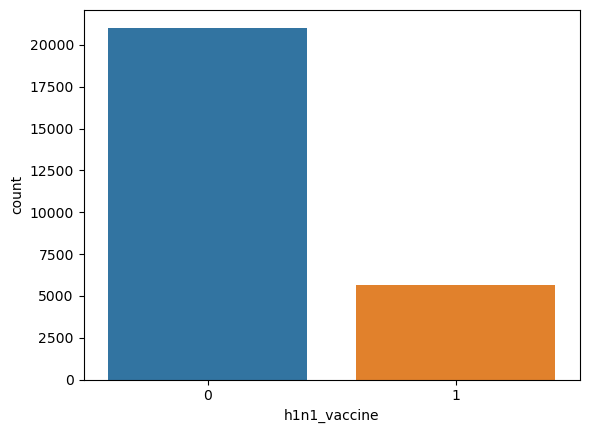

In [29]:
sns.countplot(x='h1n1_vaccine', data=df)

##### Insight:
Most individuals did not receive the vaccine → class imbalance

### Doctor recommendation vs vaccination

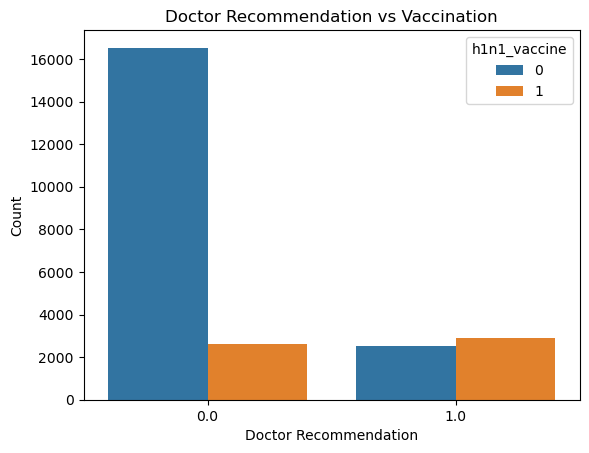

In [48]:
df['h1n1_vaccine'] = df['h1n1_vaccine'].astype(str)

sns.countplot(x='doctor_recc_h1n1', hue='h1n1_vaccine', data=df)

plt.title("Doctor Recommendation vs Vaccination")
plt.xlabel("Doctor Recommendation")
plt.ylabel("Count")
plt.savefig("../images/plots/doctor_recommendation.png") 
plt.show()

##### Insight:
The plot shows a strong relationship between doctor recommendation and vaccination.
Individuals who received a recommendation from a doctor were significantly more likely to get vaccinated.
In contrast, those who did not receive a recommendation had much lower vaccination rates.

### Age group vs vaccination

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '55 - 64 Years'),
  Text(1, 0, '35 - 44 Years'),
  Text(2, 0, '18 - 34 Years'),
  Text(3, 0, '65+ Years'),
  Text(4, 0, '45 - 54 Years')])

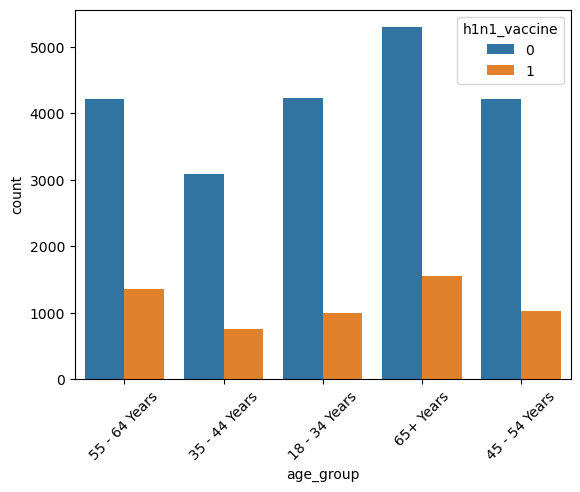

In [32]:
sns.countplot(x='age_group', hue='h1n1_vaccine', data=df)
plt.xticks(rotation=45)

##### Insight:
The distribution shows differences in vaccination rates across age groups.
Older individuals appear more likely to receive the H1N1 vaccine compared to younger individuals.

### correlation heatmap

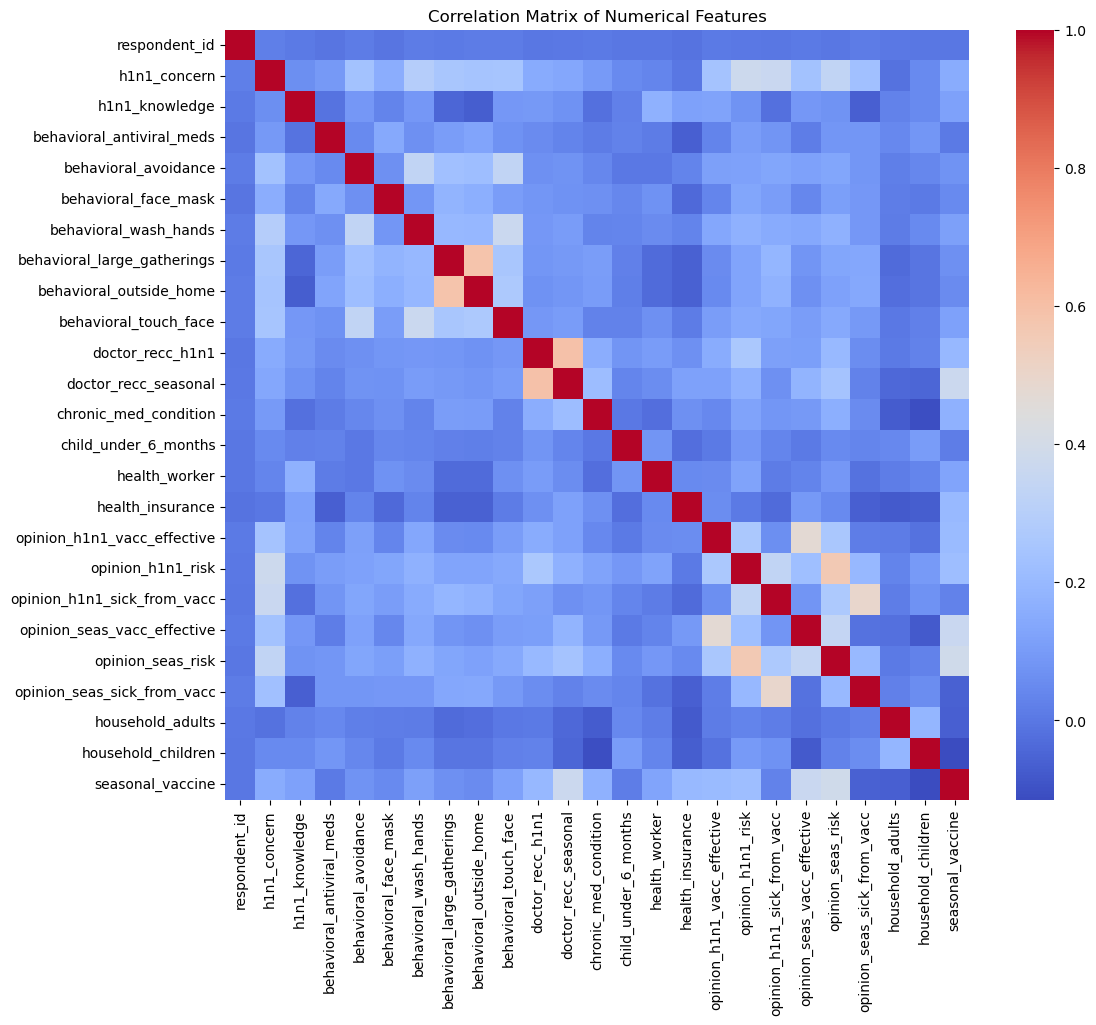

In [35]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

##### Insight:
-  The correlation matrix shows relationships between numerical variables.
- Most features have low correlation, suggesting limited multicollinearity.
- Some vaccine-related perception variables show moderate correlation,
- indicating they may influence vaccination behavior.

# Data Preparation

In this section, the dataset is prepared for machine learning modeling. This includes handling missing values, removing irrelevant variables, and preparing features for model input.

Proper data preparation is critical because machine learning models require clean, structured, and numerical data.

## Load and Merge Data

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load datasets
features = pd.read_csv("../data/raw/training_set_features.csv")
labels = pd.read_csv("../data/raw/training_set_labels.csv")

# Merge datasets
df = features.merge(labels, on="respondent_id")

# Preview data
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


The dataset has been successfully merged using respondent_id.
Each row now represents a complete record of an individual.

## Check Missing Values

In [3]:
df.isnull().sum().sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_seas_sick_from_vacc      537
opinion_seas_risk                514
opinion_seas_vacc_effective      462
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_adults                 249
household_children               249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
b

## Handle Missing Values

In [4]:
# Fill missing values with mode (most frequent value)

df.fillna(df.mode().iloc[0], inplace=True)

#####  Justification:
 Most variables are categorical or binary.
Using mode preserves the most common category and avoids unrealistic values.

## Drop Irrelevant Columns

In [5]:
df = df.drop(columns=['respondent_id', 'seasonal_vaccine'])

##### Justification:
- respondent_id is just an identifier and has no predictive value.
- seasonal_vaccine is removed to prevent data leakage.

## DEFINE FEATURES & TARGET

In [6]:
X = df.drop('h1n1_vaccine', axis=1)
y = df['h1n1_vaccine']

##### Insight:
- The target variable is binary (0 = no vaccine, 1 = vaccinated).
- This confirms that the problem is a classification task.

## IDENTIFY COLUMN TYPES

In [7]:
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns


The dataset contains both numerical and categorical features.
Therefore, we will apply scaling to numerical variables and encoding to categorical variables.

## TRAIN-TEST SPLIT

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### Justification:
Splitting the data ensures that model performance is evaluated on unseen data,
which helps assess generalization ability.

# BUILD PIPELINE

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


In [19]:
print(X_train.shape, X_test.shape)

(21365, 35) (5342, 35)


##### Insight:
A pipeline automates preprocessing and modeling steps,
ensuring consistency, preventing data leakage,
and improving reproducibility.

# REUSABLE EVALUATION FUNCTION

#### Model Evaluation Function

To improve code quality and reproducibility, a reusable evaluation function is defined.

This function standardizes:
- Model training
- Predictions
- Evaluation metrics
- Visualization

This ensures that all models are evaluated consistently, improving comparability, reproducibility, and code quality.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Create pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train model
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # Metrics
    print("Model:", model.__class__.__name__)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model.__class__.__name__} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return pipe

# Modeling

## 1. Logistic Regression

Model: LogisticRegression
Accuracy: 0.8395731935604642

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90      4212
           1       0.70      0.43      0.53      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.69      0.72      5342
weighted avg       0.83      0.84      0.82      5342

AUC: 0.831368866029633


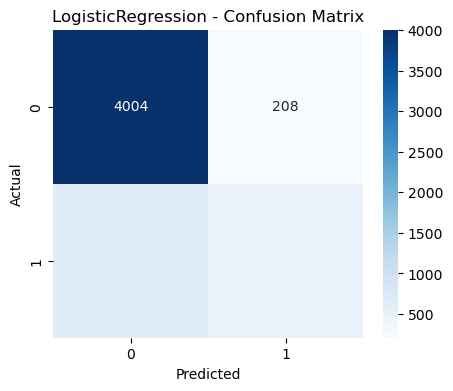

In [21]:
log_model = evaluate_model(
    LogisticRegression(max_iter=1000),
    X_train, X_test, y_train, y_test
)

## 2. Decision Tree

Model: DecisionTreeClassifier
Accuracy: 0.7588918008236616

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      4212
           1       0.43      0.45      0.44      1130

    accuracy                           0.76      5342
   macro avg       0.64      0.65      0.64      5342
weighted avg       0.76      0.76      0.76      5342

AUC: 0.6463664708502467


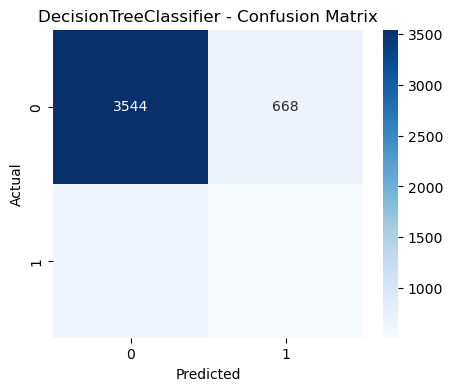

In [22]:
tree_model = evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test
)

## 3. Random Forest

Model: RandomForestClassifier
Accuracy: 0.8375140396855111

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90      4212
           1       0.72      0.38      0.50      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.67      0.70      5342
weighted avg       0.82      0.84      0.82      5342

AUC: 0.8303800141189521


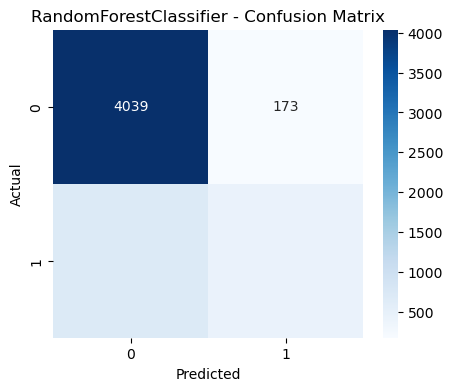

In [23]:
rf_model = evaluate_model(
    RandomForestClassifier(random_state=42),
    X_train, X_test, y_train, y_test
)

## Hyperparameter Tuning (Decision Tree)


Hyperparameter tuning improves model performance by selecting optimal parameters.
The best combination balances model complexity and generalization.

In [49]:
from sklearn.model_selection import GridSearchCV

# Create pipeline with Decision Tree
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Parameters to tune
params = {
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

# Grid Search
grid = GridSearchCV(pipe, params, cv=5, scoring="accuracy")

grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 2}


#### Evaluate tuned model

In [50]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4212
           1       0.69      0.42      0.52      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.68      0.71      5342
weighted avg       0.82      0.84      0.82      5342



Hyperparameter tuning was performed using GridSearchCV to improve model performance.

By testing multiple parameter combinations, the model identifies the best configuration that balances bias and variance.

## Cross-Validation

Cross-validation is used to evaluate how well the model generalizes to unseen data.

Using a pipeline ensures that preprocessing steps are applied consistently within each fold, preventing data leakage.

In [25]:
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipe, X_train, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Mean score:", scores.mean())

Cross-validation scores: [0.83173414 0.83758484 0.83852095 0.83454248 0.83758484]
Mean score: 0.8359934472267728


##### Insight:
- Cross-validation provides a more reliable estimate of model performance.
- Consistent scores indicate that the model generalizes well and is not overfitting.

## Model Evaluation

#### ROC Curve

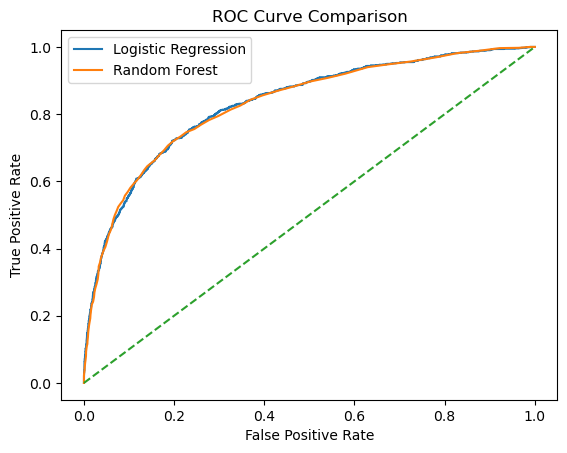

In [46]:
# Logistic
y_prob_log = log_model.predict_proba(X_test)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

# Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot both
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("../images/plots/roc_curve.png")  # ✅ SAVE HERE
plt.show()

#### Insight:
- Logistic Regression and Random Forest both perform well, with strong separation between classes.
- Logistic Regression remains competitive despite being simpler.

## Feature Importance 

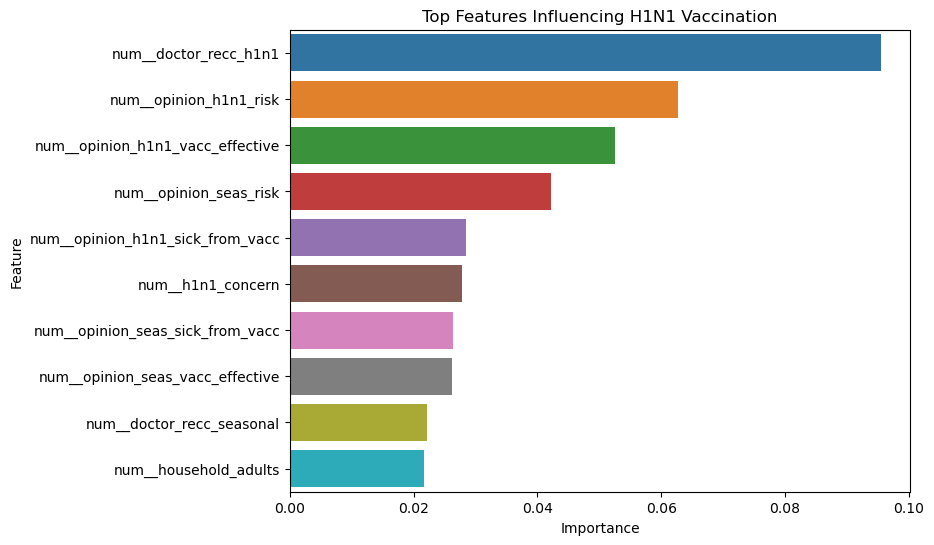

In [47]:
# Get feature names AFTER preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get importance
rf_model_step = rf_model.named_steps["model"]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model_step.feature_importances_
})

# Sort
importance = importance.sort_values(by="Importance", ascending=False)

# Top 10
top_features = importance.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Features Influencing H1N1 Vaccination")
plt.savefig("../images/plots/feature_importance.png")
plt.show()

#### Insight:
- Feature importance reveals that doctor recommendation is the strongest predictor, followed by risk perception and vaccine effectiveness.This highlights the importance of both medical advice and personal beliefs.

## Model Comparison

The performance of different models is compared using accuracy scores.

In [26]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_model.predict(X_test)),
        accuracy_score(y_test, tree_model.predict(X_test)),
        accuracy_score(y_test, rf_model.predict(X_test))
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.839573
1,Decision Tree,0.758892
2,Random Forest,0.837514


##### Interpretation:
- Logistic Regression achieved the highest accuracy, followed closely by Random Forest. Decision Tree performed worst due to overfitting.

## Bias-Variance Tradeoff

Logistic Regression is a relatively simple model, which gives it higher bias but lower variance. This means it may not capture complex patterns, but it generalizes well to new data.

Decision Trees have low bias but high variance. They can capture complex relationships but are prone to overfitting.

Random Forest reduces variance by combining multiple decision trees, improving generalization compared to a single tree.

In this project, Logistic Regression provided the best balance between bias and variance, resulting in strong and stable performance.

## Final Model Selection

Logistic Regression was selected as the final model.

Although Random Forest also performed well, Logistic Regression achieved the highest accuracy and demonstrated stable performance across cross-validation.

Additionally, Logistic Regression offers strong interpretability, which is important for public health stakeholders who need to understand the factors influencing vaccination behavior.

Therefore, Logistic Regression provides the best balance between performance, stability, and interpretability.

# Key Insights

- Doctor recommendation is the strongest predictor of vaccination.
- Individuals with higher perceived risk are more likely to vaccinate.
- Healthcare workers show higher vaccination uptake.
- Older individuals are more likely to vaccinate than younger populations.
- Class imbalance affects model performance, particularly recall.
- Logistic Regression provides the best balance between performance and interpretability.

## Limitations

- The dataset is based on self-reported survey data, which may contain inaccuracies.
- The data reflects the 2009 H1N1 pandemic, and vaccination behavior may have changed over time.
- Missing values were handled using imputation, which may introduce bias.
- The dataset is imbalanced, affecting model performance, particularly recall.
- Important external factors such as healthcare access and misinformation are not included.
- Machine learning models identify patterns but do not establish causal relationships.

# Future Recommendations

- Strengthen doctor-patient communication, as medical advice is the strongest driver of vaccination behavior.
- Implement continuous public awareness campaigns to improve risk perception before outbreaks occur.
- Target populations with historically low vaccination uptake, particularly younger individuals.
- Use data-driven approaches and machine learning to identify and engage hesitant populations.
- Integrate vaccination reminders into routine healthcare systems using digital tools.
- Improve accessibility and infrastructure to ensure rapid and widespread vaccine distribution during future outbreaks.

# Conclusion

This project aimed to predict H1N1 vaccine uptake using machine learning models based on demographic characteristics, health behaviors, and vaccine perceptions.

Several classification models were developed and evaluated, including Logistic Regression, Decision Tree, and Random Forest. Among these, Logistic Regression provided the best balance between performance and interpretability, achieving strong accuracy and consistent results across cross-validation.

The analysis identified key factors influencing vaccination behavior. Doctor recommendation emerged as the strongest predictor, followed by perceived risk and beliefs about vaccine effectiveness. Additionally, demographic factors such as age played a role, with older individuals more likely to receive the vaccine.

These findings highlight the importance of medical advice and risk awareness in shaping vaccination decisions. By leveraging these insights, public health organizations can design more effective vaccination campaigns and improve uptake.

Overall, this project demonstrates how machine learning can be used not only to predict behavior but also to generate actionable insights that support data-driven decision-making in public health.